In [ ]:
print("gello")

gello


In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from utils.stats_dataset import analyser_variables_binaires
from utils.feature_transformer import transform_features, _convert_all_columns_to_numeric
from utils.data_quality import nettoyer_nan_par_colonne
from utils.data_quality import analyser_nan,nettoyer_lignes_vides,nettoyer_colonnes
from utils.feature_loader import load_feature_lists
import sys
# loads the col
FEATURE_CONFIG_PATH = "utils/feature_columns.json"
feature_lists = load_feature_lists(FEATURE_CONFIG_PATH)
Liste_features_simple = feature_lists["Liste_features_simple"]
features_radiology_dysfunction = feature_lists["features_radiology_dysfunction"]
features_etiology = feature_lists["features_etiology"]
features_death = feature_lists["death"]
# Charger le fichier Excel
df = pd.read_excel(r"C:\Users\romai\Desktop\travail\EFRAIM3 JD VANCE.xlsx")

# séparer colonnes explicatives et etiology
df = df[df['Etiology_Undetermined cause_Definitive diagnosis'] != 1]
features_etiology.remove('Etiology_Undetermined cause_Definitive diagnosis')
Liste_features = Liste_features_simple + features_radiology_dysfunction
df_col_utils = df[Liste_features]
df_category = df[features_etiology]
df_death = df[features_death]
L_fill_mediane = ["Age"	,"Time H-ICU"	,"TIME SYMPTOMES-ICU","SOFA_score","Neutrophils","Temp","Sp02","PaO2/FiO2 VALUE VALUE","Resp_rate","Leukocytes","Quad_no"]
strategie_fill_nan = {
    col: "median" if col in L_fill_mediane else "zero"
    for col in Liste_features
}
sys.modules.pop('utils.feature_transformer', None)
sys.modules.pop('utils.data_quality', None)
sys.modules.pop('utils.stats_dataset', None)
sys.modules.pop('utils.algo_prediction', None)

df_col_utils = nettoyer_nan_par_colonne(df_col_utils,strategie_fill_nan)
df_features_clean = transform_features(df_col_utils)
# resultats = analyser_nan(df_col_utils, top_n=3)
# resultats_y = analyser_nan(df_category, top_n=8)
df_category = nettoyer_colonnes(df_category)
df_cat_clean,index_a_drop = nettoyer_lignes_vides(df_category)
df_features_clean = df_features_clean.drop(index=index_a_drop)
df_features_clean = _convert_all_columns_to_numeric(df_features_clean)


🔹 Age → NaN remplacés par la médiane (64.0)
🔹 Time H-ICU → NaN remplacés par la médiane (2.0)
🔹 TIME SYMPTOMES-ICU → NaN remplacés par la médiane (2.0)
🔹 SOFA_score → NaN remplacés par la médiane (7.0)
🔹 Resp_rate → NaN remplacés par la médiane (30.0)
🔹 Temp → NaN remplacés par la médiane (37.3)
🔹 PaO2/FiO2 VALUE VALUE → NaN remplacés par la médiane (88.0)
🔹 Neutrophils → NaN remplacés par la médiane (7.17)
🔹 Leukocytes → NaN remplacés par la médiane (9.51)
🔹 Quad_no → NaN remplacés par la médiane (3.0)

✅ Nettoyage terminé. NaN restants : 0
Nombre de lignes totalement vides : 3055


In [38]:
import sys
sys.modules.pop('utils.feature_importance', None)
sys.modules.pop('utils.data_quality', None)
sys.modules.pop('utils.stats_dataset', None)
sys.modules.pop('utils.algo_prediction', None)

sys.modules.pop('utils.visualisation', None)
sys.modules.pop('utils.data_aug', None)
sys.modules.pop('utils.models_and_metrics', None) 

<module 'utils.models_and_metrics' from 'c:\\Users\\romai\\Desktop\\codes\\respiratory_diagnostics\\utils\\models_and_metrics.py'>

In [6]:
L = df_features_clean.columns
print(L)
print("Alveolar_cons_Focal" in L)

Index(['Sex', 'Time H-ICU', 'TIME SYMPTOMES-ICU', 'Time  DG-ICU', 'Sys_dis',
       'Solid_tumor', 'Organ_transpl', 'Drug_induced', 'Chemotherapy',
       'Ibr_Flu_Met', 'Immuno_drugs', 'Tar_ther', 'Immunotherapy',
       'Carttcells', 'Steroids_YN', 'Charlson_index',
       'Prophylaxis_pneumocystis', 'Prophylaxis_antifungal',
       'Prophylaxis_bacterial', 'Prophylaxis_viral', 'Vaccins#Flu',
       'Vaccins#COVID', 'Vaccins#Other', 'Glasgow', 'Hemoptysis',
       'PaO2/FiO2 VALUE VALUE', 'Pleural_eff', 'Quad_no', 'Excavation',
       'Septal_line', 'Halo_sign', 'Lymph_bulky', 'Age_scaled', 'Hem_mal_AML',
       'Hem_mal_ALL', 'Hem_mal_Non_hodgkin_lymphoma', 'Hem_mal_myeloma',
       'Hem_mal_hodgkin_lymphoma', 'Hem_mal_CLL', 'Hem_mal_CML', 'Hem_mal_MDS',
       'Hem_mal_other', 'Disease_status_inaugural', 'Disease_status_remission',
       'Disease_status_evolutive', 'rejet_allograft', 'HSCT_BMT_Autograft',
       'HSCT_BMT_Allograft', 'Nodules_any', 'GGO', 'SOFA_scaled', 'Sa02',
  

# Mapping classes

In [64]:
# format mapping_etiology[nvelle_col] = [old_col1,old_cold2 ,...]
mapping_etiology ={
                    'Bacterial infection' :['Bacterial infection'] ,
                    'Viral infection' :['Viral infection'] ,
                    'Invasive pulmonary aspergillosis' :['Invasive pulmonary aspergillosis'] ,
                    'All fungus' : ["Other fungal ",'Mucorales'],
                    # 'Other fungal' :["Other fungal "] ,
                    # 'Mucorales' : ['Mucorales'],
                    'Pneumocystis jirovecii infection' :[ 'Pneumocystis jirovecii infection'],
                    'Cardiogenic pulmonary oedema' : ['Cardiogenic pulmonary oedema'],
                    'Disease-related infiltrates':['Disease-related infiltrates'],
                    'Drug toxicity related' : ['Drug toxicity related'],
                    'Other non infectious causes': ['Other non infectious causes','Other infection ','Transfusion-related acute lung injury'],
                   # 'Undetermined cause':['Undetermined cause' ]
                    }
from utils.data_quality import fusionner_labels
print(df_cat_clean.columns)
df_labels_fusion = fusionner_labels(df_cat_clean, mapping_etiology, mode="max")
print(df_labels_fusion.columns)

Index(['Bacterial infection', 'Viral infection',
       'Invasive pulmonary aspergillosis', 'Pneumocystis jirovecii infection',
       'Mucorales', 'Other fungal ', 'Other infection ',
       'Cardiogenic pulmonary oedema', 'Drug toxicity related',
       'Disease-related infiltrates', 'Transfusion-related acute lung injury',
       'Other non infectious causes'],
      dtype='object')
Index(['Bacterial infection', 'Viral infection',
       'Invasive pulmonary aspergillosis', 'All fungus',
       'Pneumocystis jirovecii infection', 'Cardiogenic pulmonary oedema',
       'Disease-related infiltrates', 'Drug toxicity related',
       'Other non infectious causes'],
      dtype='object')


# Model 1 classe

In [43]:
sys.modules.pop("utils.run_model")

<module 'utils.run_model' from 'c:\\Users\\romai\\Desktop\\codes\\respiratory_diagnostics\\utils\\run_model.py'>


📊 Répartition des classes : pos=0.054, neg=0.946
⚖️ Dataset déséquilibré ? → True
🧪 Activation automatique du class_weight / auto-balancing

==== All fungus ====
Meilleur combo -> Modele: Random Forest | Augmentation: BorderlineSMOTE | roc_auc: 0.7925
Negative Predictive Value (best combo): 0.9813519813519813


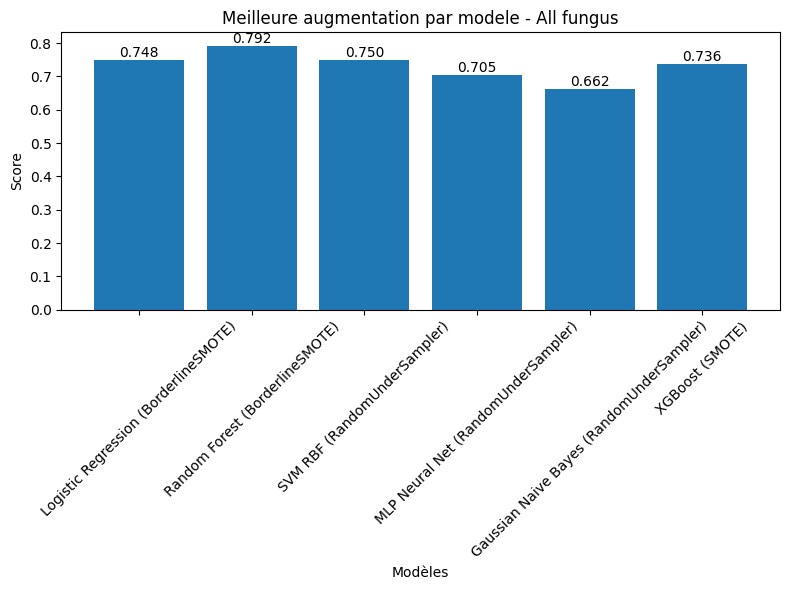

Configuration sauvegard?e dans config_All fungus.yaml


In [65]:
from utils.algo_prediction import preparer_jeu_xy, AutoStandardScaler
from utils.models_and_metrics import get_models, get_metric, negative_predictive_value,f1_metric_xgb,save_best_combo_config
from utils.data_aug import get_augmentation_methods
from utils.visualisation import show_metrics_binary, show_roc_curve,plot_model_bars
from utils.run_model import run_model_aug, run_config_for_target


def find_best_model_and_aug(df_features_clean, 
                   df_labels_fusion, 
                   target_col,
                   MODEL_NAMES,
                   MAIN_METRIC_NAME,
                   THRESHOLD,
                   write_config = False):
    """
    Lance l'experience pour une cible (diagnostic).

    Returns
    -------
    dict contenant les informations du meilleur combo modele/augmentation.
    Si write_config=True, sauvegarde config_{diagnosis}.yaml.
    """
    combo_scores = {}
    model_best_scores = {}
    model_best_aug = {}
    best_result = {
        "score": float('-inf'),
        "model_name": None,
        "augmentation_name": None,
        "pipe_train": None,
        "pipe_inference": None,
        "y_pred": None
    }

    df_labels_1 = df_labels_fusion[target_col].to_frame()
    X_train, X_test, y_train, y_test, labels = preparer_jeu_xy(df_features_clean, df_labels_1)

    all_models = get_models(y_train, use_catboost=False,imbalance_threshold=1)
    augmentations = get_augmentation_methods(random_state=0)
    metrics = get_metric()

    metric_fn = metrics[MAIN_METRIC_NAME]["metric_fn"]
    needs_proba = metrics[MAIN_METRIC_NAME]["needs_proba"]
    feature_names = X_train.columns
    print("====", target_col, "====")

    for model_name in MODEL_NAMES:
        if model_name not in all_models:
            print(f"{model_name} indisponible dans la librairie de modeles, combo ignore.")
            continue
        base_model = all_models[model_name]

        best_score_for_model = float('-inf')
        best_aug_for_model = None

        for augmentation_name, augmentation in augmentations.items():
            result = run_model_aug(
                model_name=model_name,
                base_model=base_model,
                augmentation_name=augmentation_name,
                augmentation=augmentation,
                X_train=X_train,
                X_test=X_test,
                y_train=y_train,
                y_test=y_test,
                MAIN_METRIC_NAME=MAIN_METRIC_NAME,
                metric_fn=metric_fn,
                needs_proba=needs_proba,
                THRESHOLD=THRESHOLD,
                target_col=target_col,
                feature_names=feature_names,
                
                verbose= False
            )

            score = result["score"]
            combo_key = f"{model_name} | {augmentation_name}"
            combo_scores[combo_key] = score

            if score > best_result["score"]:
                best_result.update({
                    "score": score,
                    "model_name": model_name,
                    "augmentation_name": augmentation_name,
                    "pipe_train": result["pipe_train"],
                    "pipe_inference": result["pipe_inference"],
                    "y_pred": result["y_pred"]
                })

            if score > best_score_for_model:
                best_score_for_model = score
                best_aug_for_model = augmentation_name

        if best_aug_for_model is not None:
            model_best_scores[model_name] = best_score_for_model
            model_best_aug[model_name] = best_aug_for_model


    best_model_name = best_result["model_name"]
    best_aug_name = best_result["augmentation_name"]
    best_score = best_result["score"]
    best_y_pred = best_result["y_pred"]

    print("Meilleur combo -> Modele:", best_model_name, "| Augmentation:", best_aug_name, f"| {MAIN_METRIC_NAME}: {best_score:.4f}")

    if best_y_pred is not None:
        y_pred_bin = (best_y_pred > THRESHOLD).astype(int)
        print("Negative Predictive Value (best combo):", negative_predictive_value(y_test, y_pred_bin))

    if model_best_scores:
        labelled_scores = {f"{model} ({model_best_aug[model]})": score for model, score in model_best_scores.items()}
        plot_model_bars(labelled_scores, title=f"Meilleure augmentation par modele - {target_col}")

    if write_config and best_result["model_name"] is not None:
        save_best_combo_config(target_col, best_result["model_name"], best_result["augmentation_name"], MAIN_METRIC_NAME, best_result["score"], THRESHOLD)
    elif write_config:
        print('Impossible de sauvegarder la configuration : aucun combo valide.')

    return best_result


target_col = 'All fungus'
MODEL_NAMES = ['Logistic Regression', 'Random Forest', 'SVM RBF', 'MLP Neural Net', 'Gaussian Naive Bayes', 'XGBoost']
# MODEL_NAMES =  ['Random Forest']
MAIN_METRIC_NAME = 'roc_auc'
THRESHOLD = 0.11
features_sensibilite =  ["Neutropenie", "Prophylaxis_antifungal"]
_ = find_best_model_and_aug(df_features_clean, 
                   df_labels_fusion, 
                   target_col,
                   MODEL_NAMES,
                   MAIN_METRIC_NAME,
                   THRESHOLD,
                   write_config = True)


📊 Répartition des classes : pos=0.054, neg=0.946
⚖️ Dataset déséquilibré ? → True
🧪 Activation automatique du class_weight / auto-balancing

==== All fungus ====
Meilleur combo -> Modele: Random Forest | Augmentation: SMOTE | roc_auc: 0.7908
Negative Predictive Value (best combo): 0.9817945383615084


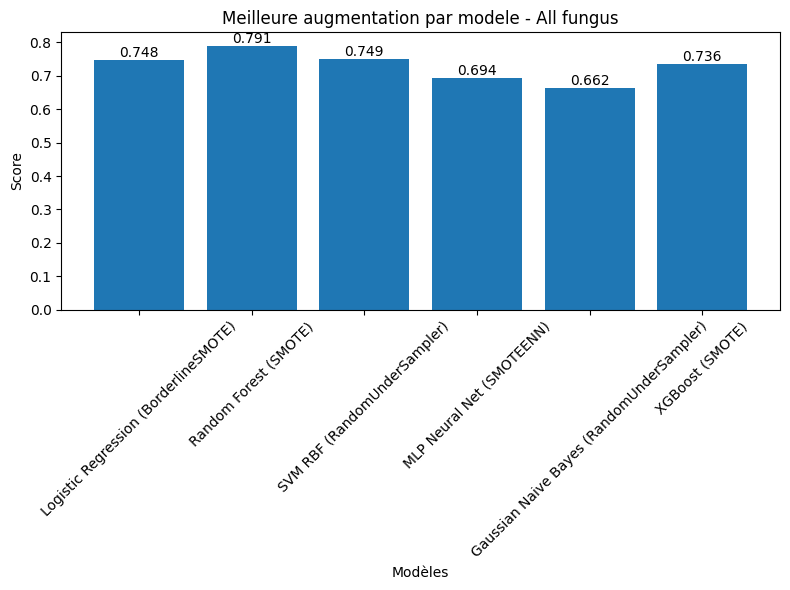

Configuration sauvegard?e dans config_All fungus.yaml


In [66]:
df_labels_fusion.columns
# big loop 
#for target_col in df_labels_fusion.columns:
target_col = 'All fungus'
MODEL_NAMES = ['Logistic Regression', 'Random Forest', 'SVM RBF', 'MLP Neural Net', 'Gaussian Naive Bayes', 'XGBoost']
# MODEL_NAMES =  ['Random Forest']
MAIN_METRIC_NAME = 'roc_auc'
THRESHOLD = 0.11
features_sensibilite =  ["Neutropenie", "Prophylaxis_antifungal"]
_ = find_best_model_and_aug(df_features_clean, 
                df_labels_fusion, 
                target_col,
                MODEL_NAMES,
                MAIN_METRIC_NAME,
                THRESHOLD,
                write_config = True)

# A implementer

In [26]:
df_labels_1 = df_labels_fusion[target_col].to_frame()
X_train, X_test, y_train, y_test, labels = preparer_jeu_xy(df_features_clean, df_labels_1)

model = get_models(y_train, use_catboost=False)['Random Forest']
from utils.feature_importance import _ensure_estimators
_ensure_estimators(model)


📊 Répartition des classes : pos=0.132, neg=0.868
⚖️ Dataset déséquilibré ? → True
🧪 Activation automatique du class_weight / auto-balancing



[RandomForestClassifier(class_weight='balanced', n_estimators=300)]

In [52]:
df_labels_fusion.columns

Index(['Bacterial infection', 'Viral infection',
       'Invasive pulmonary aspergillosis', 'Other fungal', 'Mucorales',
       'Pneumocystis jirovecii infection', 'Cardiogenic pulmonary oedema',
       'Disease-related infiltrates', 'Drug toxicity related',
       'Other non infectious causes'],
      dtype='object')

Filtrage du jeu de test via condition_test -> 61 échantillons.

📊 Répartition des classes : pos=0.052, neg=0.948
⚖️ Dataset déséquilibré ? → True
🧪 Activation automatique du class_weight / auto-balancing

Chargement configuration : c:\Users\romai\Desktop\codes\respiratory_diagnostics\configs\config_Pneumocystis jirovecii infection.yaml
Modèle = Random Forest | Augmentation = No Augmentation | Métrique = roc_auc
----- run_model_aug -----
target_col=Pneumocystis jirovecii infection
model=Random Forest
augmentation=No Augmentation
metric=roc_auc | threshold=0.11
show_roc=True, show_importance=False, show_shap=False
sensibilite=False, type_sensi=all
features_sensibilite=['Neutropenie', 'Prophylaxis_antifungal']
Random Forest | No Augmentation -> roc_auc: 0.3882
Negative Predictive Value: 0.9259259259259259


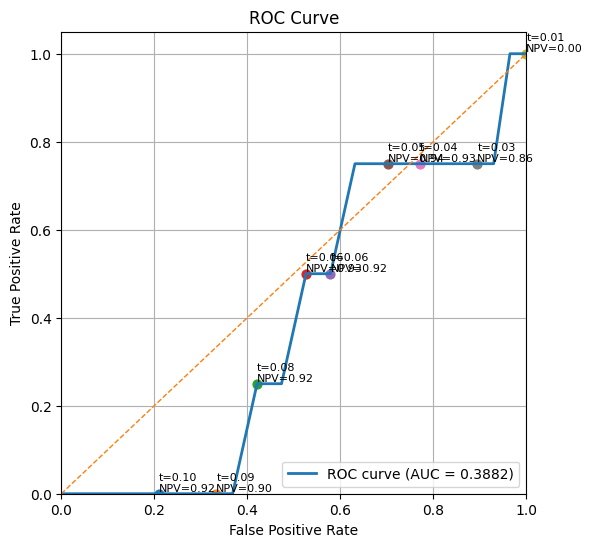

ROC AUC = 0.3882
Negative Predictive Value youden: 0.9230769230769231 threshold  0.05333333333333334


In [80]:
sys.modules.pop('utils.run_model',None)
from utils.run_model import run_config_for_target
import os 
config_dir = os.getcwd() + '\\configs\\'
target_col = 'Pneumocystis jirovecii infection'
# cols = [ 'Other fungal', 'Mucorales',
#        'Pneumocystis jirovecii infection', 'Cardiogenic pulmonary oedema',
#        'Disease-related infiltrates', 'Drug toxicity related',
#        'Other non infectious causes']
features_sensibilite = ["Neutropenie", "Prophylaxis_antifungal"]
# for target_col in cols:
condition = lambda X: (X["HSCT_BMT_Autograft"] == 1) 
_ = run_config_for_target(target_col,
                        df_features_clean,
                        df_labels_fusion,
                        sensibilite = False,
                        show_importance = False,
                        show_roc = True,
                        show_shap = False,
                        features_sensibilite = features_sensibilite,
                        type_sensi = 'all',
                        method_importance = 'native_importance',
                        config_dir = config_dir,
                        condition_test=condition)

In [ ]:
import huggingface_hub
huggingface_hub.login()
features_hemato =['Hem_mal_AML', 'Hem_mal_ALL', 'Hem_mal_Non_hodgkin_lymphoma',
       'Hem_mal_myeloma', 'Hem_mal_hodgkin_lymphoma', 'Hem_mal_CLL',
       'Hem_mal_CML', 'Hem_mal_MDS', 'Hem_mal_other']

features_sensibilite = ["Neutropenie", "Prophylaxis_antifungal"]

diag_selected = [
    'Invasive pulmonary aspergillosis', 
    'Pneumocystis jirovecii infection',
    'Cardiogenic pulmonary oedema',
    'Disease-related infiltrates',
    # 'Viral infection',
]
#target_col = 'Cardiogenic pulmonary oedema'

MODEL_NAMES = ['Logistic Regression', 'Random Forest', 'SVM RBF', 'MLP Neural Net', 'Gaussian Naive Bayes', 'XGBoost']
#MODEL_NAMES = ['TabPFN']
MODEL_NAMES =  ['Random Forest']
MAIN_METRIC_NAME = 'roc_auc'
THRESHOLD = 0.11
for target_col in diag_selected:
    run_for_target(df_features_clean, 
                   df_labels_fusion, 
                   target_col,
                   MODEL_NAMES,
                   MAIN_METRIC_NAME,
                   THRESHOLD,
                   sensibilite = False,
                   show_roc = False,
                   show_importance=True,
                   features_sensibilite = features_sensibilite ,
                   type_sensi = 'all')


In [64]:
-0.0058 / 0.178

-0.03258426966292135

In [51]:
import huggingface_hub
huggingface_hub.login()

# Multioutput

In [2]:
from imblearn.pipeline import Pipeline
from utils.algo_prediction import preparer_jeu_xy

from utils.algo_prediction import AutoStandardScaler
from utils.models_and_metrics import get_models,get_metric,f1_metric_xgb
from utils.data_aug import get_augmentation_methods
from utils.visualisation import show_metrics_binary, show_roc_curve
from utils.models_and_metrics import negative_predictive_value
from sklearn.metrics import (roc_auc_score)
from utils.visualisation import multilabel_roc
import numpy as np
X_train, X_test, y_train, y_test, labels = preparer_jeu_xy(df_features_clean,df_labels_fusion) 

models = get_models(y_train,multilabel=True,imbalance_threshold=0.01,use_catboost=False)
augmentations = get_augmentation_methods(random_state=0)
print(augmentations.keys())

metrics = get_metric()
print(metrics.keys())

results = []
metrique = f1_metric_xgb
for model_name, model in models.items():
    print("Model:", model_name)
    
    pipe_train = Pipeline([
        ("scaler", AutoStandardScaler()),
        # ("augmentation", augmentations['SMOTE']),
        ("model",model )
    ])
    # Changement de la métrique plus tard
    # pipe_train.set_params(model__eval_metric=f1_metric_xgb)


    pipe_train.fit(X_train, y_train)

    metric_fn=metrics['roc_auc']["metric_fn"]
    needs_proba=metrics['roc_auc']["needs_proba"]


    pipe_test = Pipeline([
        ("scaler", pipe_train.named_steps["scaler"]),  # scaler déjà fit
        ("model", pipe_train.named_steps["model"])     # modèle déjà fit
    ])

    if needs_proba:
        y_pred = pipe_test.predict_proba(X_test)
    else:
        y_pred = pipe_test.predict(X_test)
    probas_array = np.column_stack([p[:, 1] for p in y_pred])

    a = multilabel_roc(
        np.array(y_test), probas_array,
        plot=True,
        label_names=y_test.columns.to_list(),
        per_label_max=8,   # ne tracer que les 8 meilleures courbes par label
        show_micro=True,
        show_macro=True
        )

    # score = roc_auc_score(y_test, y_pred, average="macro")
    # show_metrics_binary(y_test, y_pred)
    # show_roc_curve(y_test, y_pred)
    # print("Negative Predictive Value:", negative_predictive_value(y_test, y_pred))

NameError: name 'df_features_clean' is not defined

In [ ]:
from utils.models_and_metrics import get_models_multilabel, compare_models_metric, get_metric
from sklearn.metrics import hamming_loss
from sklearn.metrics import f1_score
from utils.algo_prediction import preparer_jeu_xy,normaliser_features,train_and_optimize_threshold_PR
# Charger les mod?les multilabel sp?cialis?s
models = get_models_multilabel()

metrics = get_metric()
# print(metrics['f1']'metric_fn')
# Pr?parer les donn?es
X_train, X_test, y_train, y_test, labels = preparer_jeu_xy(df_features_clean, df_labels_fusion)

# Comparer avec une m?trique multilabel
df_scores = compare_models_metric(
    models,
    metric_fn=f1_score,  # ou f1_score avec un autre average
    metric_kwargs={"average": "weighted"},
    metric_name="f1_weighted",
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    needs_proba=False
)

print(df_scores)



🏷️ Mode MULTILABEL spécialisé : 7 modèles chargés


c:\Users\phili\Desktop\codes\aphp\respiratory_diagnostics\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    6.5s finished
c:\Users\phili\Desktop\codes\aphp\respiratory_diagnostics\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the conve

⚠️ MLkNN : erreur during training → ignoré.
'DataFrame' object has no attribute 'getformat'


c:\Users\phili\Desktop\codes\aphp\respiratory_diagnostics\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   14.9s finished
c:\Users\phili\Desktop\codes\aphp\respiratory_diagnostics\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the conve


🏆 CLASSEMENT DES MODÈLES PAR F1_WEIGHTED :

                   Modèle  f1_weighted
0             XGBoost OVR     0.356920
5          Label Powerset     0.355293
3       Classifier Chains     0.305704
2  Logistic Regression BR     0.300135
1       Random Forest OVR     0.296605
4                   RAkEL     0.294989
                   Modèle  f1_weighted
0             XGBoost OVR     0.356920
5          Label Powerset     0.355293
3       Classifier Chains     0.305704
2  Logistic Regression BR     0.300135
1       Random Forest OVR     0.296605
4                   RAkEL     0.294989


c:\Users\phili\Desktop\codes\aphp\respiratory_diagnostics\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:  2.0min finished
c:\Users\phili\Desktop\codes\aphp\respiratory_diagnostics\.venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


# SHAP values

In [ ]:
sys.modules.pop('utils.feature_importance', None)
from utils.feature_importance import shap_top10_per_estimator,plot_top10_features_per_estimator
plot_top10_features_per_estimator(modele,feature_names=X_train.columns,col_names=y_train.columns,to_save=True,dir_save='E:/graphs_bdd/importance')
shap_top10_per_estimator(model= modele,X = X_test_sc,col_names=y_train.columns,to_save=True,dir_save='E:/graphs_bdd/shap')

In [ ]:
from utils.stats_dataset import analyze_collinearity
from utils.data_quality import analyser_nan,nettoyer_lignes_vides,nettoyer_colonnes
from utils.feature_transformer import transform_features, _convert_all_columns_to_numeric
from utils.data_quality import nettoyer_nan_par_colonne
Liste_features = Liste_features_simple #+ features_radiology_dysfunction
df_col_utils = df[Liste_features]
df_category = df[features_etiology]
L_fill_mediane = ["Age"	,"Time H-ICU"	,"TIME SYMPTOMES-ICU","SOFA_score","Neutrophils","Temp","Sp02","PaO2/FiO2 VALUE VALUE","Resp_rate","Leukocytes","Quad_no"]
strategie_fill_nan = {
    col: "median" if col in L_fill_mediane else "zero"
    for col in Liste_features
}
df_col_utils = _convert_all_columns_to_numeric(df_col_utils)
# print(df_col_utils.columns)

df_col_utils = nettoyer_nan_par_colonne(df_col_utils,strategie_fill_nan)
df_features_clean = transform_features(df_col_utils)
df_features_clean = _convert_all_columns_to_numeric(df_features_clean)

df_category = nettoyer_colonnes(df_category)
df_cat_clean = nettoyer_lignes_vides(df_category)
df_col_utils = nettoyer_lignes_vides(df_col_utils)
vif_results = analyze_collinearity(df_col_utils)
vif_results_clean = analyze_collinearity(df_features_clean)




In [ ]:
df_col_utils.isna().any().any()
# print(df_features_clean.isna().sum()[df_features_clean.isna().sum() > 0])


In [ ]:
L_radio = ['Alveolar_xray_No', 'Alveolar_xray_Focal',
       'Alveolar_xray_Diffuse', 'Interst_xray_No', 'Interst_xray_Focal',
       'Interst_xray_Diffuse', 'Alveolar_cons_No', 'Alveolar_cons_Focal',
       'Alveolar_cons_Diffuse', 'Ground_glass_op_No', 'Ground_glass_op_Focal',
       'Ground_glass_op_Diffuse', 'rejet_allograft', 'HSCT_BMT_Autograft',
       'HSCT_BMT_Allograft', 'SOFA_scaled', 'Sa02', 'Resp_severity',
       'Temp_gravité', 'Neutropenie']
for x in L_radio:
    print(df_features_clean[x].value_counts())

In [ ]:
df_features_clean.iloc[0]

In [ ]:
Implémenter from sklearn.model_selection import StratifiedKFold
